# EDA Panel Model Selat Sunda

Chl-a bulanan, SST, dan angin pada 148 grid selama Januari 2003 sampai Desember 2025.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path(r'D:/thesis')
PANEL_PATH = ROOT / 'data' / 'processed' / 'model_dataset' / 'selat_sunda_monthly_panel_200301_202512_v1.csv'
TABLE_DIR = ROOT / 'output' / 'tables'
FIGURE_DIR = ROOT / 'output' / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

In [3]:
required = [
    'month', 'grid_id', 'lon', 'lat', 'chla_mg_m3', 'sst_c', 'sst_anomaly_c',
    'u10_m_s', 'v10_m_s', 'wind_speed_m_s', 'chla_observed',
    'predictors_complete', 'model_complete',
]

panel = pd.read_csv(PANEL_PATH, usecols=required, parse_dates=['month'], dtype={'grid_id': str})
panel = panel.sort_values(['month', 'grid_id']).reset_index(drop=True)

assert not panel.duplicated(['month', 'grid_id']).any(), 'Ada kombinasi month-grid_id duplikat.'
assert panel.shape[0] == panel.month.nunique() * panel.grid_id.nunique(), 'Panel tidak seimbang.'

print(f'Panel: {len(panel):,} baris = {panel.grid_id.nunique()} grid x {panel.month.nunique()} bulan')
print(f'Periode: {panel.month.min():%Y-%m} s.d. {panel.month.max():%Y-%m}')
print(f'Chl-a tersedia: {panel.chla_observed.mean():.1%}')
display(panel.head())

Panel: 40,848 baris = 148 grid x 276 bulan
Periode: 2003-01 s.d. 2025-12
Chl-a tersedia: 97.2%


,month,grid_id,lon,lat,chla_mg_m3,sst_c,sst_anomaly_c,u10_m_s,v10_m_s,wind_speed_m_s,chla_observed,predictors_complete,model_complete
0,2003-01-01,G025_R380_C1132,103.125,-5.125,0.108442,29.388709,0.800000,1.467873,-0.808632,1.675869,True,True,True
1,2003-01-01,G025_R380_C1133,103.375,-5.125,0.139465,29.471612,0.900968,1.358009,-0.695351,1.525681,True,True,True
2,2003-01-01,G025_R380_C1134,103.625,-5.125,0.236359,29.547741,0.994194,1.390236,-0.304237,1.423136,True,True,True
3,2003-01-01,G025_R380_C1135,103.875,-5.125,0.544038,29.567741,1.034839,0.987892,0.073692,0.990637,True,True,True
4,2003-01-01,G025_R380_C1143,105.875,-5.125,2.665797,29.211290,0.800645,1.377541,-0.493202,1.463170,True,True,True


## Ringkasan per Bulan

In [4]:
monthly = (
    panel.groupby('month', as_index=False)
    .agg(
        n_grids=('grid_id', 'size'),
        n_chla_observed=('chla_observed', 'sum'),
        chla_mean_mg_m3=('chla_mg_m3', 'mean'),
        chla_median_mg_m3=('chla_mg_m3', 'median'),
        sst_mean_c=('sst_c', 'mean'),
        sst_anomaly_mean_c=('sst_anomaly_c', 'mean'),
        u10_mean_m_s=('u10_m_s', 'mean'),
        v10_mean_m_s=('v10_m_s', 'mean'),
        wind_speed_mean_m_s=('wind_speed_m_s', 'mean'),
    )
)
monthly['chla_availability_fraction'] = monthly.n_chla_observed / monthly.n_grids
monthly.to_csv(TABLE_DIR / 'monthly_regional_summary_v1.csv', index=False, encoding='utf-8-sig')
display(monthly.head())

,month,n_grids,n_chla_observed,chla_mean_mg_m3,chla_median_mg_m3,sst_mean_c,sst_anomaly_mean_c,u10_mean_m_s,v10_mean_m_s,wind_speed_mean_m_s,chla_availability_fraction
0,2003-01-01,148,148,0.287315,0.135536,29.002944,0.477073,2.400480,0.613962,2.612342,1.0
1,2003-02-01,148,148,0.399821,0.136571,28.687485,0.090709,3.516873,-2.265397,4.196870,1.0
2,2003-03-01,148,148,0.406794,0.210474,28.644590,-0.333446,0.015007,-0.116231,0.493587,1.0
3,2003-04-01,148,148,0.297295,0.168056,29.817317,0.583847,-2.575959,0.966478,2.783075,1.0
4,2003-05-01,148,148,0.328175,0.163857,29.245084,0.062842,-3.170641,1.402598,3.488410,1.0


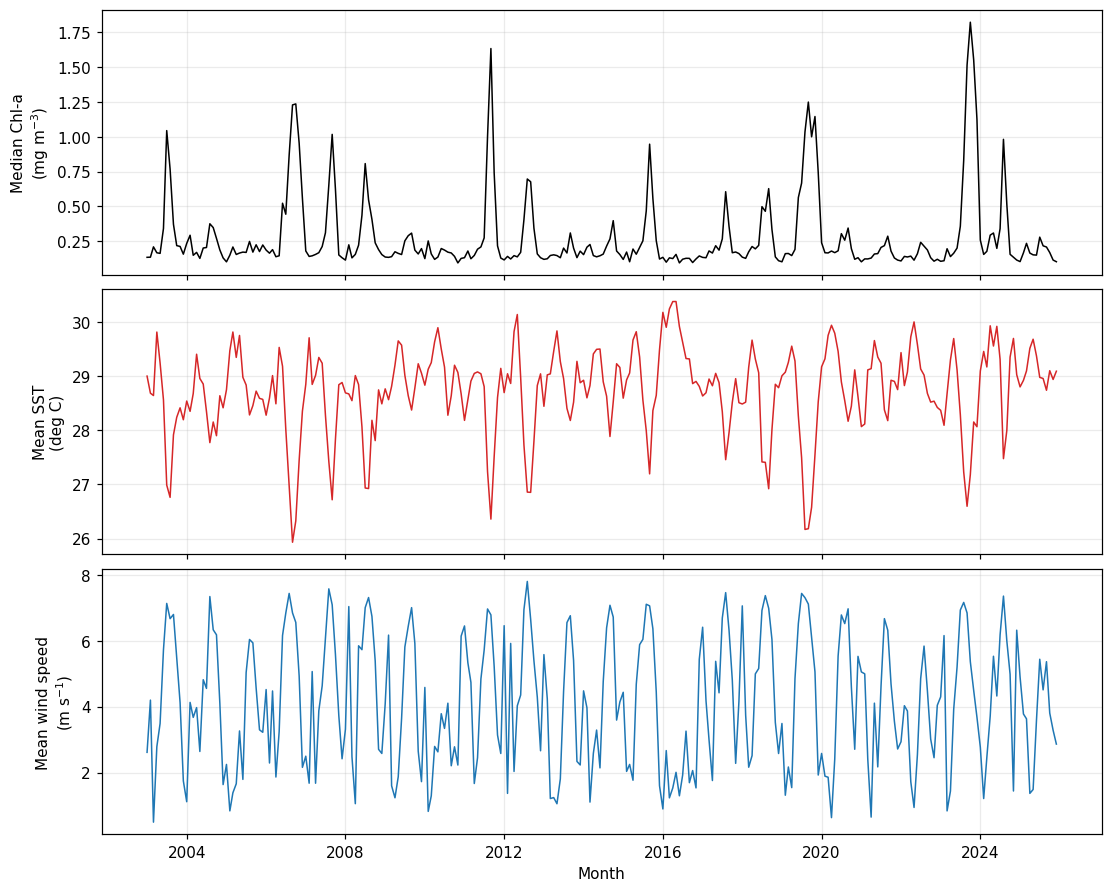

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

axes[0].plot(monthly.month, monthly.chla_median_mg_m3, color='black', linewidth=1)
axes[0].set_ylabel('Median Chl-a\n(mg m$^{-3}$)')

axes[1].plot(monthly.month, monthly.sst_mean_c, color='tab:red', linewidth=1)
axes[1].set_ylabel('Mean SST\n(deg C)')

axes[2].plot(monthly.month, monthly.wind_speed_mean_m_s, color='tab:blue', linewidth=1)
axes[2].set_ylabel('Mean wind speed\n(m s$^{-1}$)')
axes[2].set_xlabel('Month')

fig.savefig(FIGURE_DIR / 'temporal_overview_v1.png', dpi=220, bbox_inches='tight')
plt.show()

## Pola Musiman

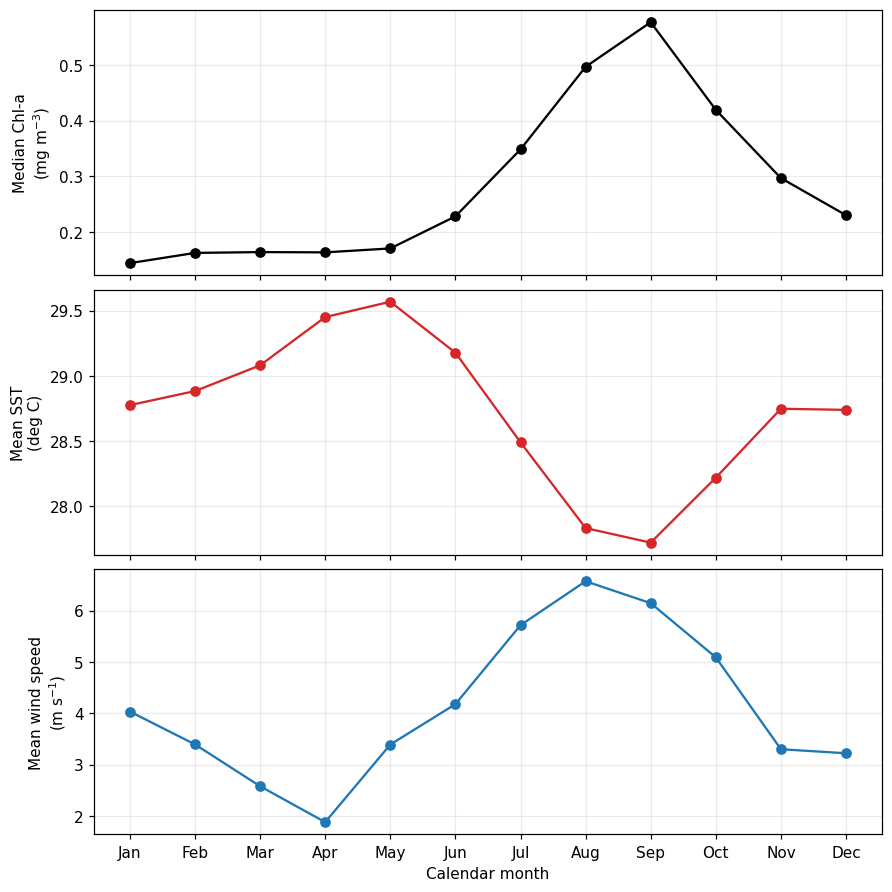

In [6]:
seasonal = (
    monthly.assign(calendar_month=monthly.month.dt.month)
    .groupby('calendar_month', as_index=False)
    .agg(
        chla_median_mg_m3=('chla_median_mg_m3', 'mean'),
        sst_mean_c=('sst_mean_c', 'mean'),
        wind_speed_mean_m_s=('wind_speed_mean_m_s', 'mean'),
    )
)

labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True, constrained_layout=True)
axes[0].plot(seasonal.calendar_month, seasonal.chla_median_mg_m3, marker='o', color='black')
axes[0].set_ylabel('Median Chl-a\n(mg m$^{-3}$)')
axes[1].plot(seasonal.calendar_month, seasonal.sst_mean_c, marker='o', color='tab:red')
axes[1].set_ylabel('Mean SST\n(deg C)')
axes[2].plot(seasonal.calendar_month, seasonal.wind_speed_mean_m_s, marker='o', color='tab:blue')
axes[2].set_ylabel('Mean wind speed\n(m s$^{-1}$)')
axes[2].set_xlabel('Calendar month')
axes[2].set_xticks(range(1, 13), labels)
fig.savefig(FIGURE_DIR / 'seasonal_cycle_v1.png', dpi=220, bbox_inches='tight')
plt.show()

## Ringkasan Spasial

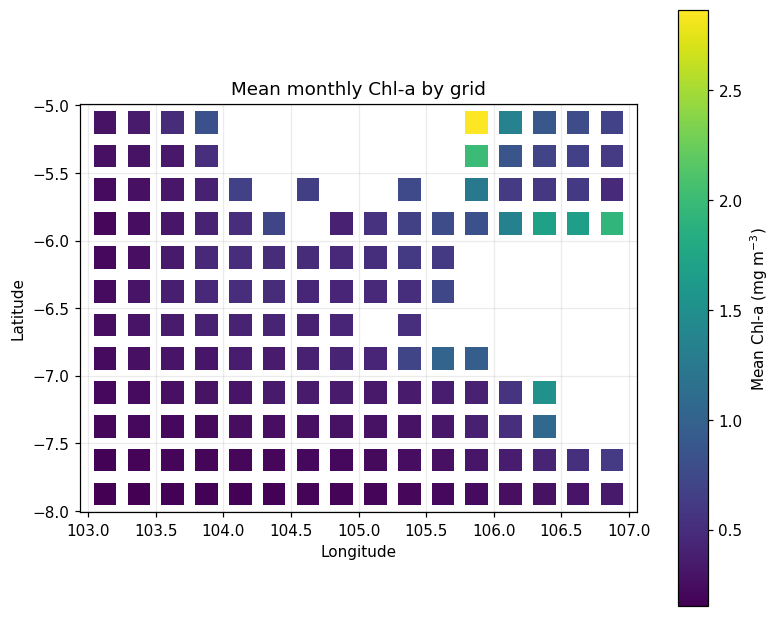

In [7]:
grid_summary = (
    panel.groupby('grid_id', as_index=False)
    .agg(
        lon=('lon', 'first'),
        lat=('lat', 'first'),
        n_months=('month', 'size'),
        n_chla_observed=('chla_observed', 'sum'),
        chla_mean_mg_m3=('chla_mg_m3', 'mean'),
        chla_median_mg_m3=('chla_mg_m3', 'median'),
        sst_mean_c=('sst_c', 'mean'),
        wind_speed_mean_m_s=('wind_speed_m_s', 'mean'),
    )
)
grid_summary['chla_availability_fraction'] = grid_summary.n_chla_observed / grid_summary.n_months
grid_summary.to_csv(TABLE_DIR / 'grid_summary_v1.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
points = ax.scatter(
    grid_summary.lon, grid_summary.lat, c=grid_summary.chla_mean_mg_m3,
    marker='s', s=220, cmap='viridis', edgecolors='none',
)
fig.colorbar(points, ax=ax, label='Mean Chl-a (mg m$^{-3}$)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mean monthly Chl-a by grid')
ax.set_aspect('equal', adjustable='box')
fig.savefig(FIGURE_DIR / 'mean_chla_grid_v1.png', dpi=220, bbox_inches='tight')
plt.show()

## Hubungan Awal dengan Lag

In [8]:
rows = []
for predictor in ['sst_mean_c', 'sst_anomaly_mean_c', 'u10_mean_m_s', 'v10_mean_m_s', 'wind_speed_mean_m_s']:
    for lag in range(4):
        paired = pd.DataFrame({
            'chla': monthly.chla_median_mg_m3,
            'predictor': monthly[predictor].shift(lag),
        }).dropna()
        rows.append({
            'predictor': predictor,
            'lag_months': lag,
            'n_pairs': len(paired),
            'pearson_r': paired.chla.corr(paired.predictor, method='pearson'),
            'spearman_rho': paired.chla.corr(paired.predictor, method='spearman'),
        })

lagged = pd.DataFrame(rows)
lagged.to_csv(TABLE_DIR / 'lagged_regional_association_v1.csv', index=False, encoding='utf-8-sig')
display(lagged.round(3))

,predictor,lag_months,n_pairs,pearson_r,spearman_rho
0,sst_mean_c,0,276,-0.745,-0.524
1,sst_mean_c,1,275,-0.609,-0.371
2,sst_mean_c,2,274,-0.320,-0.083
3,sst_mean_c,3,273,-0.035,0.177
4,sst_anomaly_mean_c,0,276,-0.663,-0.358
5,sst_anomaly_mean_c,1,275,-0.563,-0.362
6,sst_anomaly_mean_c,2,274,-0.366,-0.261
7,sst_anomaly_mean_c,3,273,-0.202,-0.201
8,u10_mean_m_s,0,276,-0.464,-0.740
9,u10_mean_m_s,1,275,-0.490,-0.669
